# **INSTALL LIBRARIES AND SETUP ENVIRONMENT**

In [7]:
!pip install -q skl2onnx onnx onnxruntime

from pathlib import Path
from collections import deque
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

import onnx
import onnxruntime as ort
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

warnings.filterwarnings("ignore")

DATASET_ROOT = Path("/content/DATASET")
OUTPUT_DIR = DATASET_ROOT

TARGET_HZ = 50
WINDOW_SECONDS = 2.0
STRIDE_SECONDS = 0.5
RANDOM_STATE = 42

NODES = (2, 3, 4)
SENSORS = ("BNO85", "ICM45686")

CLASS_NAMES = (
    "correct",
    "incomplete_range",
    "elbow_movement",
)

BNO_COLUMNS = (
    "quat_i",
    "quat_j",
    "quat_k",
    "quat_real",
    "linear_accel_x_mps2",
    "linear_accel_y_mps2",
    "linear_accel_z_mps2",
    "gravity_x_mps2",
    "gravity_y_mps2",
    "gravity_z_mps2",
    "gyro_x_radps",
    "gyro_y_radps",
    "gyro_z_radps",
)

ICM_COLUMNS = (
    "accel_x_g",
    "accel_y_g",
    "accel_z_g",
    "gyro_x_dps",
    "gyro_y_dps",
    "gyro_z_dps",
)

STATISTICS = (
    "mean",
    "std",
    "min",
    "max",
    "range",
    "iqr",
    "rms",
    "mean_abs_diff",
)

CONFIG_PATH = DATASET_ROOT / "dataset_config.json"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {CONFIG_PATH}. Upload the dataset to /content/DATASET."
    )

config = json.loads(CONFIG_PATH.read_text())
session_entries = sorted(
    config["sessions"],
    key=lambda item: int(item["session"])
)

print("Dataset:", DATASET_ROOT)
print("Sessions:", len(session_entries))
pd.DataFrame(session_entries)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 64.3 MB/s eta 0:00:00
Dataset: /content/DATASET
Sessions: 6


,session,folder,class_id,label
0,1,correct/session_01,0,correct
1,2,correct/session_02,0,correct
2,3,incomplete_range/session_03,1,incomplete_range
3,4,incomplete_range/session_04,1,incomplete_range
4,5,elbow_movement/session_05,2,elbow_movement
5,6,elbow_movement/session_06,2,elbow_movement


# **Data loading, synchronization and feature functions**

In [8]:
def sensor_columns(sensor):
    if sensor == "BNO85":
        return BNO_COLUMNS
    if sensor == "ICM45686":
        return ICM_COLUMNS
    raise ValueError(f"Unsupported sensor: {sensor}")


def sensor_file(entry, node, sensor):
    session = int(entry["session"])
    folder = DATASET_ROOT / entry["folder"]
    return folder / f"R{session:04d}N{node}_{sensor}.csv"


def validate_dataset():
    missing_files = []

    for entry in session_entries:
        session = int(entry["session"])

        expected_label = CLASS_NAMES[int(entry["class_id"])]
        if entry["label"] != expected_label:
            raise ValueError(
                f"Class mapping error in session {session}: "
                f"{entry['label']} != {expected_label}"
            )

        for node in NODES:
            folder = DATASET_ROOT / entry["folder"]
            required_files = [
                sensor_file(entry, node, "BNO85"),
                sensor_file(entry, node, "ICM45686"),
                folder / f"R{session:04d}N{node}_metadata.json",
            ]

            for path in required_files:
                if not path.exists():
                    missing_files.append(str(path))

    if missing_files:
        raise FileNotFoundError(
            "Missing dataset files:\n" + "\n".join(missing_files)
        )

    print("Dataset validation passed.")


def load_stream(path, columns):
    frame = pd.read_csv(
        path,
        usecols=["timestamp_us", *columns]
    )

    for column in ["timestamp_us", *columns]:
        frame[column] = pd.to_numeric(
            frame[column],
            errors="coerce"
        )

    if frame.isna().any().any():
        raise ValueError(f"Missing or non-numeric values in {path}")

    frame["time_s"] = frame.pop("timestamp_us") / 1_000_000.0

    frame = (
        frame
        .drop_duplicates("time_s", keep="last")
        .sort_values("time_s")
        .set_index("time_s")
    )

    return frame


def interpolate_stream(frame, grid):
    result = {}

    for column in frame.columns:
        result[column] = np.interp(
            grid,
            frame.index.to_numpy(),
            frame[column].to_numpy()
        )

    return pd.DataFrame(result, index=grid)


def quaternion_angle_degrees(left, right):
    left_norm = np.linalg.norm(left, axis=1, keepdims=True)
    right_norm = np.linalg.norm(right, axis=1, keepdims=True)

    left = left / np.clip(left_norm, 1e-9, None)
    right = right / np.clip(right_norm, 1e-9, None)

    dot_product = np.abs(np.sum(left * right, axis=1))
    dot_product = np.clip(dot_product, 0, 1)

    return np.degrees(2 * np.arccos(dot_product))


def assemble_synchronized_frame(raw_streams, grid):
    merged = pd.DataFrame(index=grid)

    for node in NODES:
        for sensor in SENSORS:
            stream = raw_streams[(node, sensor)]
            interpolated = interpolate_stream(stream, grid)

            if sensor == "BNO85":
                quaternion_columns = list(BNO_COLUMNS[:4])
                quaternion = interpolated[
                    quaternion_columns
                ].to_numpy(copy=True)

                norms = np.linalg.norm(
                    quaternion,
                    axis=1,
                    keepdims=True
                )

                if np.any(norms < 1e-9):
                    raise ValueError(
                        f"Zero-length quaternion detected for N{node}"
                    )

                interpolated.loc[:, quaternion_columns] = (
                    quaternion / norms
                )

                prefix = f"n{node}_bno_"
            else:
                prefix = f"n{node}_icm_"

            interpolated.columns = [
                prefix + column
                for column in interpolated.columns
            ]

            merged = merged.join(interpolated)

        magnitude_groups = {
            f"n{node}_bno_linear_accel_mag": [
                f"n{node}_bno_linear_accel_x_mps2",
                f"n{node}_bno_linear_accel_y_mps2",
                f"n{node}_bno_linear_accel_z_mps2",
            ],
            f"n{node}_bno_gyro_mag": [
                f"n{node}_bno_gyro_x_radps",
                f"n{node}_bno_gyro_y_radps",
                f"n{node}_bno_gyro_z_radps",
            ],
            f"n{node}_icm_accel_mag": [
                f"n{node}_icm_accel_x_g",
                f"n{node}_icm_accel_y_g",
                f"n{node}_icm_accel_z_g",
            ],
            f"n{node}_icm_gyro_mag": [
                f"n{node}_icm_gyro_x_dps",
                f"n{node}_icm_gyro_y_dps",
                f"n{node}_icm_gyro_z_dps",
            ],
        }

        for feature_name, columns in magnitude_groups.items():
            merged[feature_name] = np.linalg.norm(
                merged[columns].to_numpy(),
                axis=1
            )

    quaternion_suffixes = BNO_COLUMNS[:4]

    for left_node, right_node in ((2, 3), (3, 4), (2, 4)):
        left_quaternion = merged[
            [
                f"n{left_node}_bno_{suffix}"
                for suffix in quaternion_suffixes
            ]
        ].to_numpy()

        right_quaternion = merged[
            [
                f"n{right_node}_bno_{suffix}"
                for suffix in quaternion_suffixes
            ]
        ].to_numpy()

        merged[
            f"relative_angle_n{left_node}_n{right_node}_deg"
        ] = quaternion_angle_degrees(
            left_quaternion,
            right_quaternion
        )

    merged.index.name = "time_s"

    return merged


def synchronize_session(entry):
    raw_streams = {}

    for node in NODES:
        for sensor in SENSORS:
            raw_streams[(node, sensor)] = load_stream(
                sensor_file(entry, node, sensor),
                sensor_columns(sensor)
            )

    common_start = max(
        frame.index.min()
        for frame in raw_streams.values()
    )

    common_end = min(
        frame.index.max()
        for frame in raw_streams.values()
    )

    grid = np.arange(
        common_start,
        common_end,
        1.0 / TARGET_HZ
    )

    return assemble_synchronized_frame(
        raw_streams,
        grid
    )


def summarize_window(window):
    feature_values = {}

    for column in window.columns:
        signal = window[column].to_numpy(dtype=float)

        values = {
            "mean": np.mean(signal),
            "std": np.std(signal),
            "min": np.min(signal),
            "max": np.max(signal),
            "range": np.ptp(signal),
            "iqr": (
                np.percentile(signal, 75)
                - np.percentile(signal, 25)
            ),
            "rms": np.sqrt(np.mean(signal ** 2)),
            "mean_abs_diff": np.mean(
                np.abs(np.diff(signal))
            ),
        }

        for statistic in STATISTICS:
            feature_values[
                f"{column}__{statistic}"
            ] = float(values[statistic])

    return feature_values


validate_dataset()

Dataset validation passed.


# **Synchronize recordings and create training windows**

Synchronizing session 1...
Synchronizing session 2...
Synchronizing session 3...
Synchronizing session 4...
Synchronizing session 5...
Synchronizing session 6...


,session,class_id,class,samples_at_50hz,duration_seconds,channels,missing_values
0,1,0,correct,2727,54.52,72,0
1,2,0,correct,2730,54.58,72,0
2,3,1,incomplete_range,2727,54.52,72,0
3,4,1,incomplete_range,2728,54.54,72,0
4,5,2,elbow_movement,2733,54.64,72,0
5,6,2,elbow_movement,2734,54.66,72,0


,session,class_id,windows,class
0,1,0,106,correct
1,2,0,106,correct
2,3,1,106,incomplete_range
3,4,1,106,incomplete_range
4,5,2,106,elbow_movement
5,6,2,106,elbow_movement


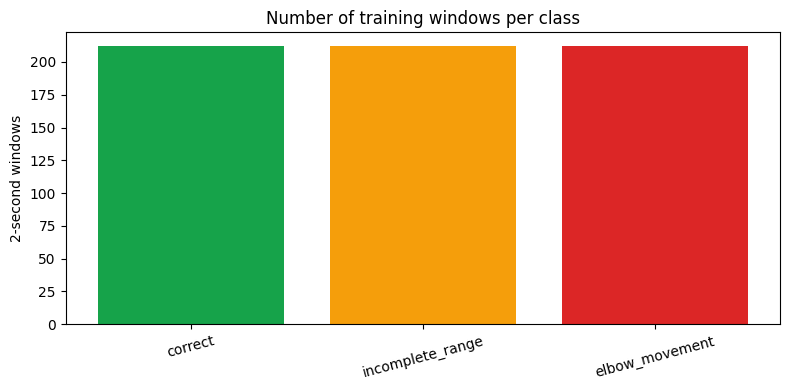

In [17]:
synchronized_sessions = {}
coverage_rows = []

for entry in session_entries:
    session = int(entry["session"])
    print(f"Synchronizing session {session}...")

    synchronized = synchronize_session(entry)
    synchronized_sessions[session] = synchronized

    coverage_rows.append({
        "session": session,
        "class_id": int(entry["class_id"]),
        "class": entry["label"],
        "samples_at_50hz": len(synchronized),
        "duration_seconds": (
            synchronized.index[-1]
            - synchronized.index[0]
        ),
        "channels": synchronized.shape[1],
        "missing_values": int(
            synchronized.isna().sum().sum()
        ),
    })

coverage = pd.DataFrame(coverage_rows)
display(coverage.round(2))

assert coverage["channels"].eq(72).all()
assert coverage["missing_values"].eq(0).all()

window_samples = int(TARGET_HZ * WINDOW_SECONDS)
stride_samples = int(TARGET_HZ * STRIDE_SECONDS)

window_rows = []

for entry in session_entries:
    session = int(entry["session"])
    class_id = int(entry["class_id"])
    frame = synchronized_sessions[session]

    for start in range(
        0,
        len(frame) - window_samples + 1,
        stride_samples
    ):
        window = frame.iloc[
            start:start + window_samples
        ]

        row = summarize_window(window)

        row.update({
            "session": session,
            "class_id": class_id,
            "window_start_s": float(window.index[0]),
            "window_end_s": float(window.index[-1]),
        })

        window_rows.append(row)

features = pd.DataFrame(window_rows)

metadata_columns = {
    "session",
    "class_id",
    "window_start_s",
    "window_end_s",
}

feature_names = [
    column
    for column in features.columns
    if column not in metadata_columns
]

assert len(feature_names) == 576
assert np.isfinite(
    features[feature_names].to_numpy()
).all()

window_counts = (
    features
    .groupby(["session", "class_id"])
    .size()
    .rename("windows")
    .reset_index()
)

window_counts["class"] = window_counts[
    "class_id"
].map(dict(enumerate(CLASS_NAMES)))

display(window_counts)

class_counts = (
    features["class_id"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))

plt.bar(
    [CLASS_NAMES[index] for index in class_counts.index],
    class_counts.values,
    color=["#16a34a", "#f59e0b", "#dc2626"]
)

plt.title("Number of training windows per class")
plt.ylabel("2-second windows")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# **Plot sensor recordings**

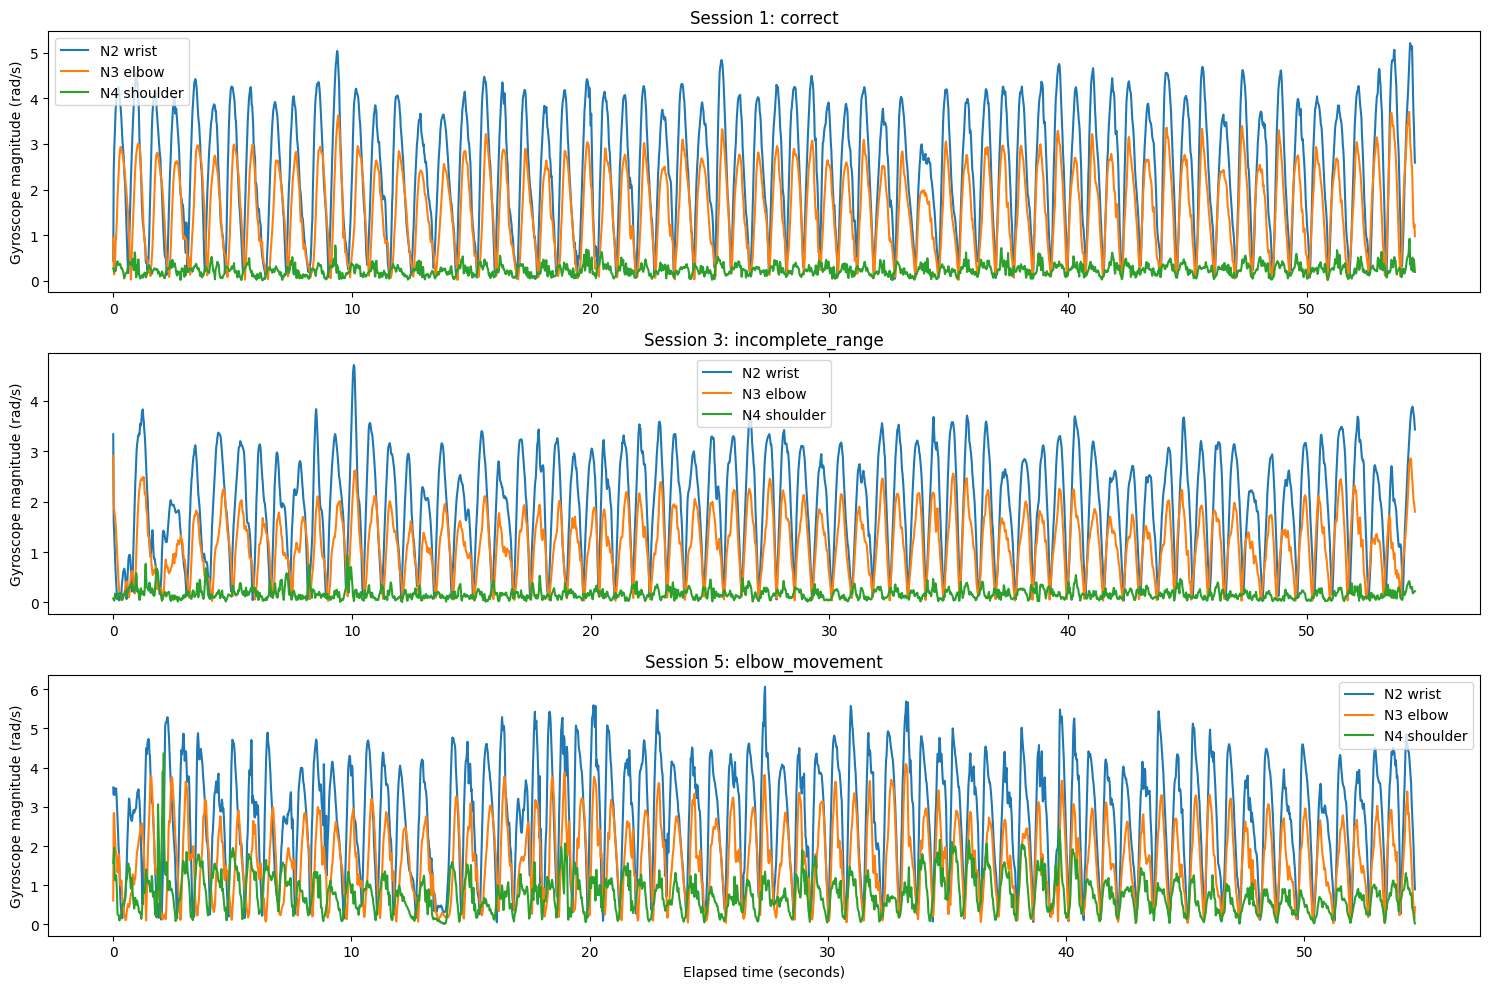

In [10]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10)
)

example_sessions = [1, 3, 5]

for axis, session in zip(axes, example_sessions):
    frame = synchronized_sessions[session]
    entry = next(
        item
        for item in session_entries
        if int(item["session"]) == session
    )

    elapsed = (
        frame.index.to_numpy()
        - frame.index[0]
    )

    axis.plot(
        elapsed,
        frame["n2_bno_gyro_mag"],
        label="N2 wrist"
    )

    axis.plot(
        elapsed,
        frame["n3_bno_gyro_mag"],
        label="N3 elbow"
    )

    axis.plot(
        elapsed,
        frame["n4_bno_gyro_mag"],
        label="N4 shoulder"
    )

    axis.set_title(
        f"Session {session}: {entry['label']}"
    )

    axis.set_ylabel("Gyroscope magnitude (rad/s)")
    axis.legend()

axes[-1].set_xlabel("Elapsed time (seconds)")

plt.tight_layout()
plt.show()

# **Session-based model evaluation and graphs**

,fold,train_sessions,test_sessions,test_windows,accuracy,balanced_accuracy,macro_f1
0,A,"[1, 3, 5]","[2, 4, 6]",318,0.953,0.953,0.953
1,B,"[2, 4, 6]","[1, 3, 5]",318,0.981,0.981,0.981


Average metrics:


,mean
accuracy,0.967
balanced_accuracy,0.967
macro_f1,0.967


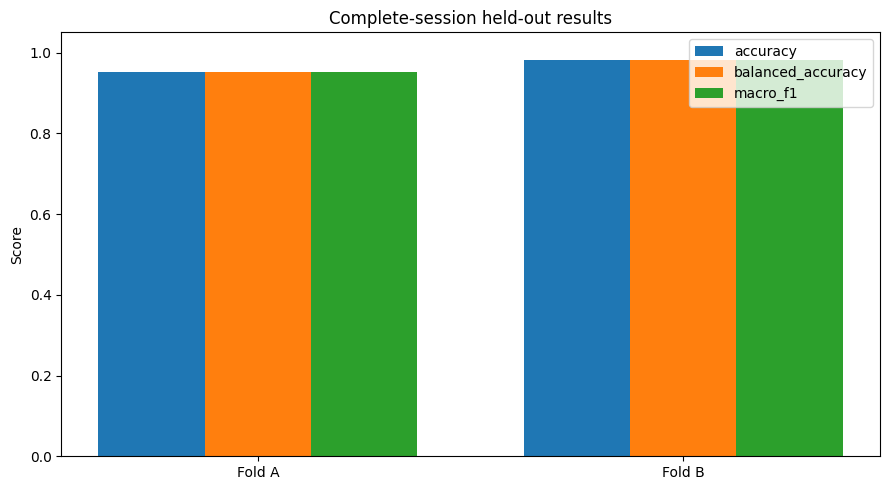

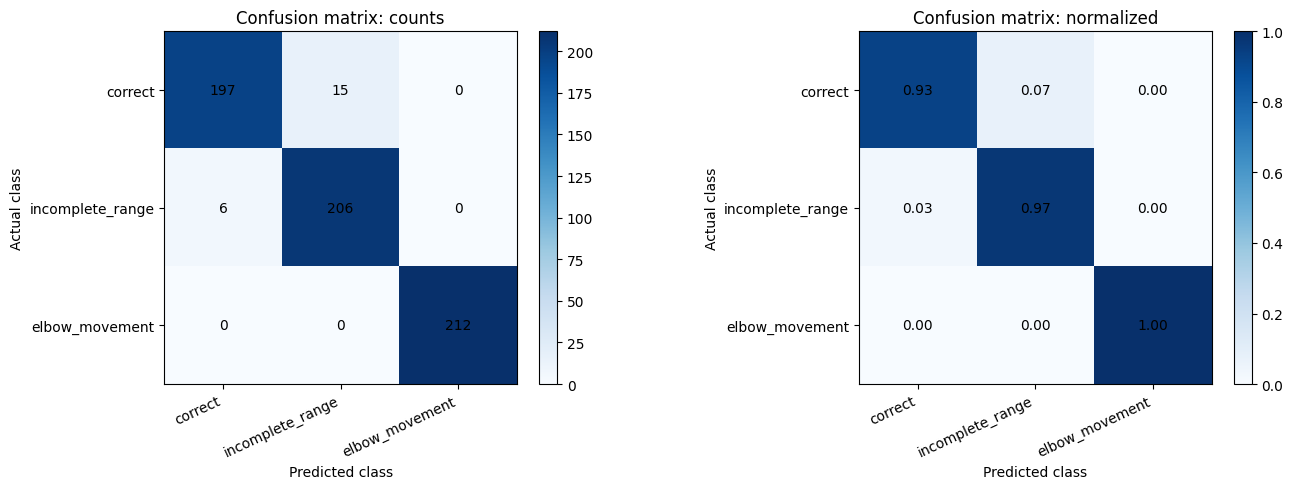

,class,precision,recall,f1,windows
0,correct,0.970,0.929,0.949,212
1,incomplete_range,0.932,0.972,0.952,212
2,elbow_movement,1.000,1.000,1.000,212


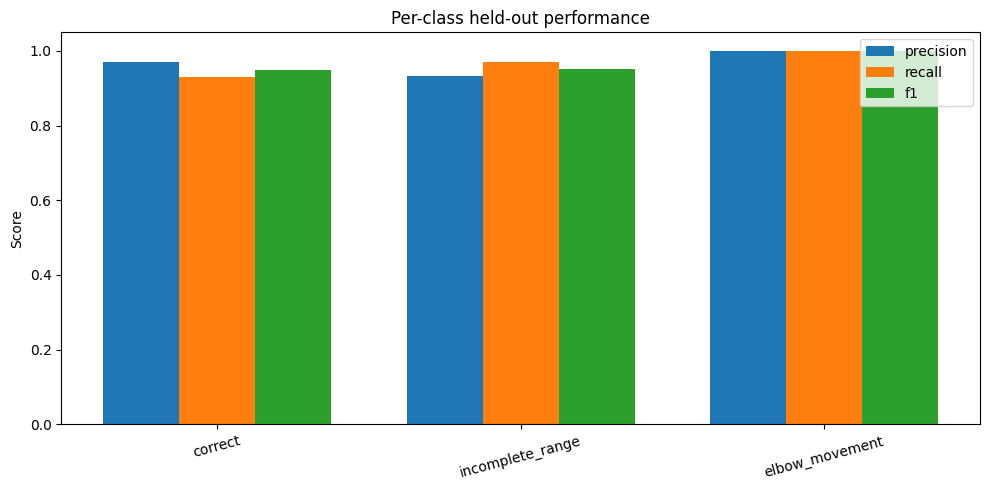

,feature,importance
386,n4_bno_gravity_z_mps2__mean,0.020000
476,n4_bno_quat_k__min,0.018005
113,n2_bno_quat_real__max,0.015503
514,n4_icm_accel_z_g__mean,0.013500
377,n4_bno_gravity_y_mps2__max,0.012505
553,relative_angle_n2_n3_deg__max,0.012000
460,n4_bno_quat_i__min,0.011009
563,relative_angle_n2_n4_deg__mean_abs_diff,0.011008
457,n4_bno_quat_i__max,0.010000
513,n4_icm_accel_z_g__max,0.009500


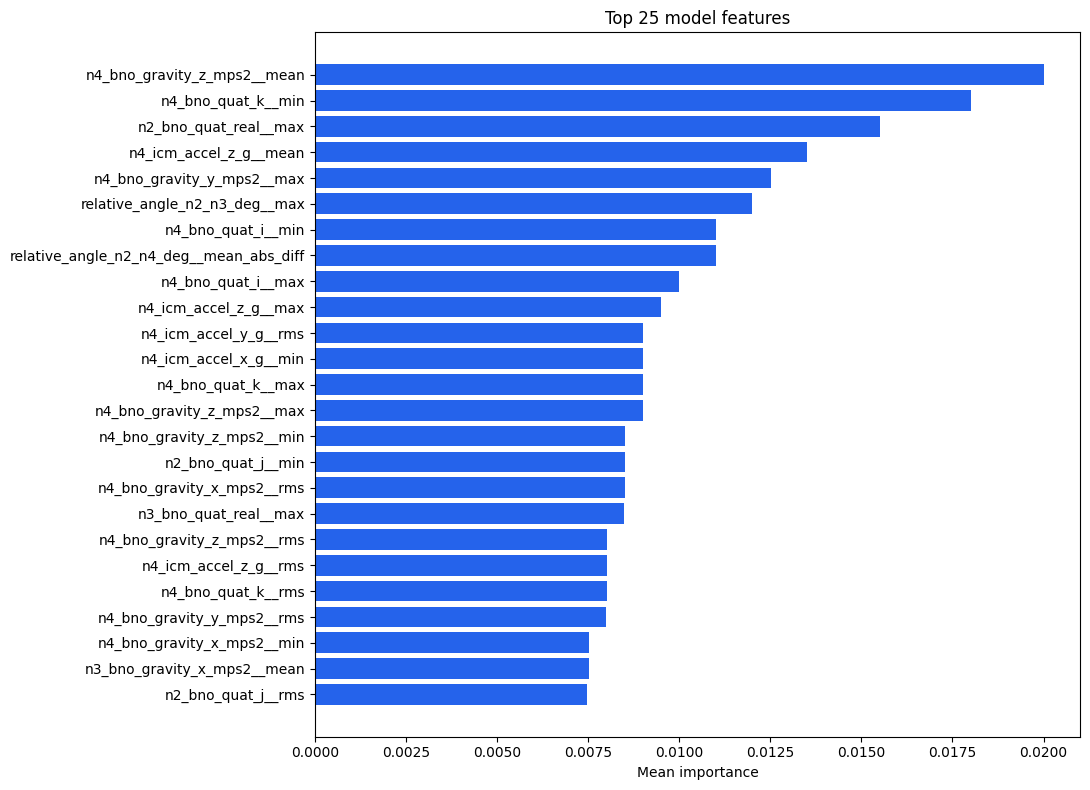

                  precision    recall  f1-score   support

         correct     0.9704    0.9292    0.9494       212
incomplete_range     0.9321    0.9717    0.9515       212
  elbow_movement     1.0000    1.0000    1.0000       212

        accuracy                         0.9670       636
       macro avg     0.9675    0.9670    0.9670       636
    weighted avg     0.9675    0.9670    0.9670       636



In [11]:
folds = config["validation_folds"]

fold_metric_rows = []
prediction_frames = []
importance_frames = []

for fold in folds:
    train_sessions = [
        int(value)
        for value in fold["train_sessions"]
    ]

    test_sessions = [
        int(value)
        for value in fold["test_sessions"]
    ]

    train_mask = features["session"].isin(
        train_sessions
    )

    test_mask = features["session"].isin(
        test_sessions
    )

    X_train = features.loc[
        train_mask,
        feature_names
    ].to_numpy(dtype=np.float32)

    y_train = features.loc[
        train_mask,
        "class_id"
    ].to_numpy(dtype=np.int64)

    X_test = features.loc[
        test_mask,
        feature_names
    ].to_numpy(dtype=np.float32)

    y_test = features.loc[
        test_mask,
        "class_id"
    ].to_numpy(dtype=np.int64)

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=14,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)

    predicted = model.predict(X_test)
    probabilities = model.predict_proba(X_test)

    fold_metric_rows.append({
        "fold": fold["name"],
        "train_sessions": train_sessions,
        "test_sessions": test_sessions,
        "test_windows": len(X_test),
        "accuracy": accuracy_score(
            y_test,
            predicted
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predicted
        ),
        "macro_f1": f1_score(
            y_test,
            predicted,
            average="macro"
        ),
    })

    prediction_frame = features.loc[
        test_mask,
        [
            "session",
            "class_id",
            "window_start_s",
            "window_end_s",
        ]
    ].copy()

    prediction_frame["fold"] = fold["name"]
    prediction_frame["predicted_class_id"] = predicted

    for class_id, class_name in enumerate(CLASS_NAMES):
        prediction_frame[
            f"probability_{class_name}"
        ] = probabilities[:, class_id]

    prediction_frames.append(prediction_frame)

    importance_frames.append(
        pd.DataFrame({
            "fold": fold["name"],
            "feature": feature_names,
            "importance": model.feature_importances_,
        })
    )

fold_metrics = pd.DataFrame(fold_metric_rows)

held_out_predictions = pd.concat(
    prediction_frames,
    ignore_index=True
)

feature_importances = pd.concat(
    importance_frames,
    ignore_index=True
)

display(fold_metrics.round(3))

print("Average metrics:")
display(
    fold_metrics[
        ["accuracy", "balanced_accuracy", "macro_f1"]
    ].mean().to_frame("mean").round(3)
)

# Fold metrics graph

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
]

x = np.arange(len(fold_metrics))
width = 0.25

plt.figure(figsize=(9, 5))

for offset, metric_name in enumerate(metric_names):
    plt.bar(
        x + (offset - 1) * width,
        fold_metrics[metric_name],
        width,
        label=metric_name
    )

plt.xticks(
    x,
    [f"Fold {name}" for name in fold_metrics["fold"]]
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Complete-session held-out results")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrices

y_true = held_out_predictions[
    "class_id"
].to_numpy()

y_predicted = held_out_predictions[
    "predicted_class_id"
].to_numpy()

count_matrix = confusion_matrix(
    y_true,
    y_predicted,
    labels=range(len(CLASS_NAMES))
)

normalized_matrix = confusion_matrix(
    y_true,
    y_predicted,
    labels=range(len(CLASS_NAMES)),
    normalize="true"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

matrix_settings = [
    (
        axes[0],
        count_matrix,
        "Confusion matrix: counts",
        "d"
    ),
    (
        axes[1],
        normalized_matrix,
        "Confusion matrix: normalized",
        ".2f"
    ),
]

for axis, matrix, title, number_format in matrix_settings:
    image = axis.imshow(
        matrix,
        cmap="Blues",
        vmin=0,
        vmax=1 if number_format == ".2f" else None
    )

    axis.set_xticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES,
        rotation=25,
        ha="right"
    )

    axis.set_yticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES
    )

    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")
    axis.set_title(title)

    for row in range(len(CLASS_NAMES)):
        for column in range(len(CLASS_NAMES)):
            axis.text(
                column,
                row,
                format(
                    matrix[row, column],
                    number_format
                ),
                ha="center",
                va="center"
            )

    fig.colorbar(
        image,
        ax=axis,
        fraction=0.046,
        pad=0.04
    )

plt.tight_layout()
plt.show()

# Per-class metrics

precision, recall, class_f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_predicted,
        labels=range(len(CLASS_NAMES)),
        zero_division=0
    )
)

per_class_metrics = pd.DataFrame({
    "class": CLASS_NAMES,
    "precision": precision,
    "recall": recall,
    "f1": class_f1,
    "windows": support,
})

display(per_class_metrics.round(3))

x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.figure(figsize=(10, 5))

for offset, metric_name in enumerate(
    ["precision", "recall", "f1"]
):
    plt.bar(
        x + (offset - 1) * width,
        per_class_metrics[metric_name],
        width,
        label=metric_name
    )

plt.xticks(x, CLASS_NAMES, rotation=15)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Per-class held-out performance")
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance

top_features = (
    feature_importances
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .head(25)
)

display(top_features)

ordered_features = top_features.sort_values(
    "importance"
)

plt.figure(figsize=(11, 8))

plt.barh(
    ordered_features["feature"],
    ordered_features["importance"],
    color="#2563eb"
)

plt.xlabel("Mean importance")
plt.title("Top 25 model features")
plt.tight_layout()
plt.show()

print(
    classification_report(
        y_true,
        y_predicted,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

# Train final model and export **ONNX**

In [12]:
X_all = features[
    feature_names
].to_numpy(dtype=np.float32)

y_all = features[
    "class_id"
].to_numpy(dtype=np.int64)

final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=14,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_model.fit(X_all, y_all)

onnx_model = convert_sklearn(
    final_model,
    name="vantare_bicep_curl_v1",
    initial_types=[
        (
            "features",
            FloatTensorType([
                None,
                len(feature_names)
            ])
        )
    ],
    target_opset={
        "": 18,
        "ai.onnx.ml": 3
    },
    options={
        id(final_model): {
            "zipmap": False
        }
    }
)

onnx_path = (
    OUTPUT_DIR
    / "vantare_bicep_curl_v1.onnx"
)

onnx_path.write_bytes(
    onnx_model.SerializeToString()
)

onnx.checker.check_model(
    onnx.load(str(onnx_path))
)

onnx_session = ort.InferenceSession(
    str(onnx_path),
    providers=["CPUExecutionProvider"]
)

input_information = onnx_session.get_inputs()[0]
output_information = onnx_session.get_outputs()

input_name = input_information.name
output_names = [
    output.name
    for output in output_information
]

# Verify exported ONNX against the trained model

verification_batch = X_all[
    :min(128, len(X_all))
]

sklearn_labels = final_model.predict(
    verification_batch
)

sklearn_probabilities = final_model.predict_proba(
    verification_batch
)

onnx_labels, onnx_probabilities = (
    onnx_session.run(
        None,
        {
            input_name: verification_batch
        }
    )
)

label_agreement = np.mean(
    np.asarray(onnx_labels).reshape(-1)
    == sklearn_labels
)

maximum_probability_difference = np.max(
    np.abs(
        np.asarray(onnx_probabilities)
        - sklearn_probabilities
    )
)

print("ONNX label agreement:", label_agreement)
print(
    "Maximum probability difference:",
    maximum_probability_difference
)

if label_agreement != 1.0:
    raise RuntimeError(
        "ONNX labels do not match the trained model."
    )

if maximum_probability_difference >= 1e-5:
    raise RuntimeError(
        "ONNX probability verification failed."
    )

# Save model details

model_contract = {
    "model_name": "vantare_bicep_curl_v1",

    "class_mapping": {
        "0": "correct",
        "1": "incomplete_range",
        "2": "elbow_movement",
    },

    "node_placement": {
        "2": "wrist_distal_forearm",
        "3": "elbow_region",
        "4": "upper_arm_near_shoulder",
    },

    "preprocessing": {
        "target_hz": TARGET_HZ,
        "window_seconds": WINDOW_SECONDS,
        "window_samples": window_samples,
        "stride_seconds": STRIDE_SECONDS,
        "synchronized_channels": 72,
        "features": len(feature_names),
    },

    "input": {
        "name": input_name,
        "dtype": "float32",
        "shape": [
            "batch_size",
            len(feature_names)
        ],
    },

    "outputs": [
        {
            "name": output_information[0].name,
            "meaning": "predicted_class_id",
            "dtype": output_information[0].type,
        },
        {
            "name": output_information[1].name,
            "meaning": "class_probabilities",
            "dtype": output_information[1].type,
            "probability_order": list(CLASS_NAMES),
        },
    ],

    "live_inference": {
        "warmup_seconds": WINDOW_SECONDS,
        "prediction_interval_seconds": (
            STRIDE_SECONDS
        ),
        "recommended_probability_threshold": 0.70,
        "required_consecutive_incorrect_windows": 2,
        "haptic_cooldown_seconds": 2.0,
    },

    "warning": (
        "Version 1 personalized model. "
        "No rest or transition class is available."
    ),
}

metrics = {
    "evaluation": (
        "two complete-session-held-out folds"
    ),

    "fold_metrics": json.loads(
        fold_metrics.to_json(
            orient="records"
        )
    ),

    "mean_accuracy": float(
        fold_metrics["accuracy"].mean()
    ),

    "mean_balanced_accuracy": float(
        fold_metrics[
            "balanced_accuracy"
        ].mean()
    ),

    "mean_macro_f1": float(
        fold_metrics["macro_f1"].mean()
    ),

    "confusion_matrix": (
        count_matrix.tolist()
    ),

    "normalized_confusion_matrix": (
        normalized_matrix.tolist()
    ),

    "onnx_label_agreement": float(
        label_agreement
    ),

    "onnx_max_probability_difference": float(
        maximum_probability_difference
    ),
}

(OUTPUT_DIR / "model_contract.json").write_text(
    json.dumps(model_contract, indent=2)
)

(OUTPUT_DIR / "metrics.json").write_text(
    json.dumps(metrics, indent=2)
)

(OUTPUT_DIR / "feature_names.json").write_text(
    json.dumps(feature_names, indent=2)
)

print("\nSaved files:")

for filename in [
    "vantare_bicep_curl_v1.onnx",
    "model_contract.json",
    "metrics.json",
    "feature_names.json",
]:
    path = OUTPUT_DIR / filename
    print(
        filename,
        "-",
        path.stat().st_size,
        "bytes"
    )

ONNX label agreement: 1.0
Maximum probability difference: 5.80688719420408e-06

Saved files:
vantare_bicep_curl_v1.onnx - 208800 bytes
model_contract.json - 1224 bytes
metrics.json - 1277 bytes
feature_names.json - 17954 bytes


# Live sensor **inference**

In [13]:
class LiveBicepCurlClassifier:
    def __init__(
        self,
        model_path,
        confidence_threshold=0.70,
        required_consecutive=2,
        haptic_cooldown_seconds=2.0,
    ):
        self.session = ort.InferenceSession(
            str(model_path),
            providers=["CPUExecutionProvider"]
        )

        self.input_name = (
            self.session.get_inputs()[0].name
        )

        self.streams = {
            (node, sensor): deque()
            for node in NODES
            for sensor in SENSORS
        }

        self.last_prediction_time = None
        self.consecutive_incorrect = 0
        self.last_haptic_time = None

        self.confidence_threshold = (
            confidence_threshold
        )

        self.required_consecutive = (
            required_consecutive
        )

        self.haptic_cooldown_seconds = (
            haptic_cooldown_seconds
        )

        self.window_samples = int(
            TARGET_HZ * WINDOW_SECONDS
        )

    def push_sample(
        self,
        node,
        sensor,
        timestamp_us,
        values
    ):
        key = (int(node), sensor)

        if key not in self.streams:
            raise ValueError(
                f"Unsupported stream: N{node} {sensor}"
            )

        required_columns = sensor_columns(sensor)

        missing = [
            column
            for column in required_columns
            if column not in values
        ]

        if missing:
            raise ValueError(
                f"Missing {sensor} values: {missing}"
            )

        timestamp_s = (
            int(timestamp_us)
            / 1_000_000.0
        )

        stream = self.streams[key]

        if stream and timestamp_s <= stream[-1][0]:
            raise ValueError(
                "Timestamps must increase "
                f"for N{node} {sensor}"
            )

        numeric_values = tuple(
            float(values[column])
            for column in required_columns
        )

        stream.append(
            (timestamp_s, numeric_values)
        )

        return self._predict_if_ready()

    def _predict_if_ready(self):
        if any(
            len(stream) < 2
            for stream in self.streams.values()
        ):
            return []

        common_start = max(
            stream[0][0]
            for stream in self.streams.values()
        )

        common_end = min(
            stream[-1][0]
            for stream in self.streams.values()
        )

        if (
            common_end - common_start
            < WINDOW_SECONDS
        ):
            return []

        if self.last_prediction_time is not None:
            time_since_prediction = (
                common_end
                - self.last_prediction_time
            )

            if (
                time_since_prediction
                < STRIDE_SECONDS
            ):
                return []

        first_grid_time = (
            common_end
            - (self.window_samples - 1)
            / TARGET_HZ
        )

        grid = (
            first_grid_time
            + np.arange(self.window_samples)
            / TARGET_HZ
        )

        raw_streams = {}

        for (node, sensor), stream in self.streams.items():
            columns = sensor_columns(sensor)
            records = list(stream)

            raw_streams[(node, sensor)] = (
                pd.DataFrame(
                    [record[1] for record in records],
                    index=[
                        record[0]
                        for record in records
                    ],
                    columns=columns
                )
            )

        synchronized_window = (
            assemble_synchronized_frame(
                raw_streams,
                grid
            )
        )

        feature_dictionary = summarize_window(
            synchronized_window
        )

        feature_vector = np.array(
            [
                feature_dictionary[name]
                for name in feature_names
            ],
            dtype=np.float32
        ).reshape(1, -1)

        labels, probabilities = (
            self.session.run(
                None,
                {
                    self.input_name: feature_vector
                }
            )
        )

        class_id = int(
            np.asarray(labels).reshape(-1)[0]
        )

        probabilities = np.asarray(
            probabilities,
            dtype=np.float32
        ).reshape(-1, len(CLASS_NAMES))[0]

        confidence = float(
            probabilities[class_id]
        )

        confident_incorrect = (
            class_id != 0
            and confidence
            >= self.confidence_threshold
        )

        if confident_incorrect:
            self.consecutive_incorrect += 1
        else:
            self.consecutive_incorrect = 0

        cooldown_ready = (
            self.last_haptic_time is None
            or common_end - self.last_haptic_time
            >= self.haptic_cooldown_seconds
        )

        trigger_haptic = (
            self.consecutive_incorrect
            >= self.required_consecutive
            and cooldown_ready
        )

        if trigger_haptic:
            self.last_haptic_time = common_end

        self.last_prediction_time = common_end

        # Remove old data to control memory use.
        removal_cutoff = (
            common_end
            - WINDOW_SECONDS
            - STRIDE_SECONDS
        )

        for stream in self.streams.values():
            while (
                len(stream) > 2
                and stream[1][0]
                < removal_cutoff
            ):
                stream.popleft()

        return [{
            "timestamp_us": int(
                common_end * 1_000_000
            ),
            "predicted_class_id": class_id,
            "predicted_label": (
                CLASS_NAMES[class_id]
            ),
            "confidence": confidence,
            "probabilities": {
                CLASS_NAMES[index]: float(
                    probabilities[index]
                )
                for index in range(
                    len(CLASS_NAMES)
                )
            },
            "trigger_haptic": trigger_haptic,
            "consecutive_incorrect": (
                self.consecutive_incorrect
            ),
        }]


live_classifier = LiveBicepCurlClassifier(
    model_path=(
        DATASET_ROOT
        / "vantare_bicep_curl_v1.onnx"
    )
)

print("Live classifier is ready.")
print(
    "It will produce its first result after "
    "receiving approximately 2 seconds of "
    "N2, N3 and N4 sensor data."
)

Live classifier is ready.
It will produce its first result after receiving approximately 2 seconds of N2, N3 and N4 sensor data.


# **Detailed training and held-out test results**

In [14]:
import time

required_variables = [
    "features",
    "feature_names",
    "config",
    "CLASS_NAMES",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "The Colab runtime is missing these variables: "
        f"{missing_variables}. Run Parts 1–3 again first."
    )

detailed_fold_results = []
all_detailed_predictions = []

for fold in config["validation_folds"]:
    fold_name = fold["name"]

    train_sessions = [
        int(session)
        for session in fold["train_sessions"]
    ]

    test_sessions = [
        int(session)
        for session in fold["test_sessions"]
    ]

    train_mask = features["session"].isin(
        train_sessions
    )

    test_mask = features["session"].isin(
        test_sessions
    )

    X_train = features.loc[
        train_mask,
        feature_names
    ].to_numpy(dtype=np.float32)

    y_train = features.loc[
        train_mask,
        "class_id"
    ].to_numpy(dtype=np.int64)

    X_test = features.loc[
        test_mask,
        feature_names
    ].to_numpy(dtype=np.float32)

    y_test = features.loc[
        test_mask,
        "class_id"
    ].to_numpy(dtype=np.int64)

    evaluation_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=14,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    training_start = time.perf_counter()

    evaluation_model.fit(
        X_train,
        y_train
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    train_predictions = evaluation_model.predict(
        X_train
    )

    test_predictions = evaluation_model.predict(
        X_test
    )

    test_probabilities = (
        evaluation_model.predict_proba(
            X_test
        )
    )

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    train_balanced_accuracy = (
        balanced_accuracy_score(
            y_train,
            train_predictions
        )
    )

    test_balanced_accuracy = (
        balanced_accuracy_score(
            y_test,
            test_predictions
        )
    )

    train_macro_f1 = f1_score(
        y_train,
        train_predictions,
        average="macro"
    )

    test_macro_f1 = f1_score(
        y_test,
        test_predictions,
        average="macro"
    )

    detailed_fold_results.append({
        "fold": fold_name,
        "train_sessions": str(train_sessions),
        "test_sessions": str(test_sessions),
        "training_windows": len(X_train),
        "testing_windows": len(X_test),
        "training_seconds": training_seconds,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "train_balanced_accuracy": (
            train_balanced_accuracy
        ),
        "test_balanced_accuracy": (
            test_balanced_accuracy
        ),
        "train_macro_f1": train_macro_f1,
        "test_macro_f1": test_macro_f1,
        "accuracy_gap": (
            train_accuracy - test_accuracy
        ),
    })

    prediction_frame = features.loc[
        test_mask,
        [
            "session",
            "class_id",
            "window_start_s",
            "window_end_s",
        ]
    ].copy()

    prediction_frame["fold"] = fold_name
    prediction_frame[
        "predicted_class_id"
    ] = test_predictions

    for class_id, class_name in enumerate(
        CLASS_NAMES
    ):
        prediction_frame[
            f"probability_{class_name}"
        ] = test_probabilities[:, class_id]

    all_detailed_predictions.append(
        prediction_frame
    )

detailed_results = pd.DataFrame(
    detailed_fold_results
)

detailed_predictions = pd.concat(
    all_detailed_predictions,
    ignore_index=True
)

display(detailed_results.round(4))

print("\nAVERAGE RESULTS")
print("-" * 50)

summary_results = {
    "Average training time (seconds)": (
        detailed_results[
            "training_seconds"
        ].mean()
    ),
    "Average training accuracy": (
        detailed_results[
            "train_accuracy"
        ].mean()
    ),
    "Average held-out test accuracy": (
        detailed_results[
            "test_accuracy"
        ].mean()
    ),
    "Average held-out balanced accuracy": (
        detailed_results[
            "test_balanced_accuracy"
        ].mean()
    ),
    "Average held-out macro F1": (
        detailed_results[
            "test_macro_f1"
        ].mean()
    ),
    "Average train/test accuracy gap": (
        detailed_results[
            "accuracy_gap"
        ].mean()
    ),
}

for name, value in summary_results.items():
    print(f"{name}: {value:.4f}")

,fold,train_sessions,test_sessions,training_windows,testing_windows,training_seconds,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_macro_f1,test_macro_f1,accuracy_gap
0,A,"[1, 3, 5]","[2, 4, 6]",318,318,4.3178,1.0,0.9528,1.0,0.9528,1.0,0.9526,0.0472
1,B,"[2, 4, 6]","[1, 3, 5]",318,318,5.4682,1.0,0.9811,1.0,0.9811,1.0,0.9811,0.0189



AVERAGE RESULTS
--------------------------------------------------
Average training time (seconds): 4.8930
Average training accuracy: 1.0000
Average held-out test accuracy: 0.9670
Average held-out balanced accuracy: 0.9670
Average held-out macro F1: 0.9669
Average train/test accuracy gap: 0.0330


# Accuracy, overfitting and per-class **graphs**

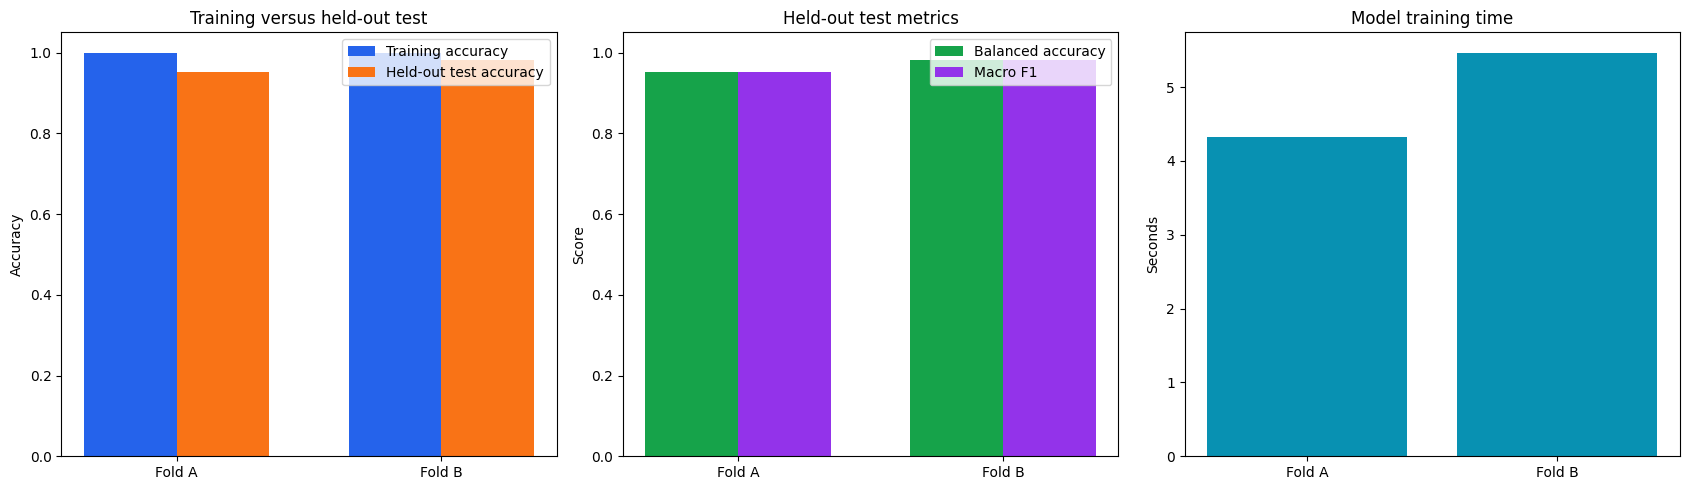

COMBINED HELD-OUT TEST REPORT
------------------------------------------------------------
                  precision    recall  f1-score   support

         correct     0.9704    0.9292    0.9494       212
incomplete_range     0.9321    0.9717    0.9515       212
  elbow_movement     1.0000    1.0000    1.0000       212

        accuracy                         0.9670       636
       macro avg     0.9675    0.9670    0.9670       636
    weighted avg     0.9675    0.9670    0.9670       636



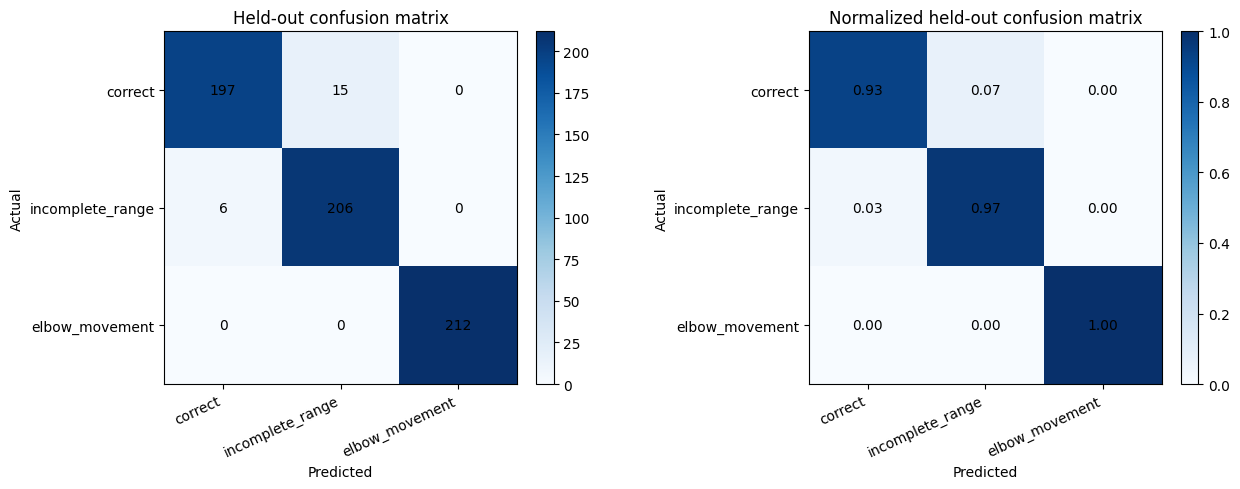

,class,precision,recall,f1,held_out_windows
0,correct,0.9704,0.9292,0.9494,212
1,incomplete_range,0.9321,0.9717,0.9515,212
2,elbow_movement,1.0000,1.0000,1.0000,212


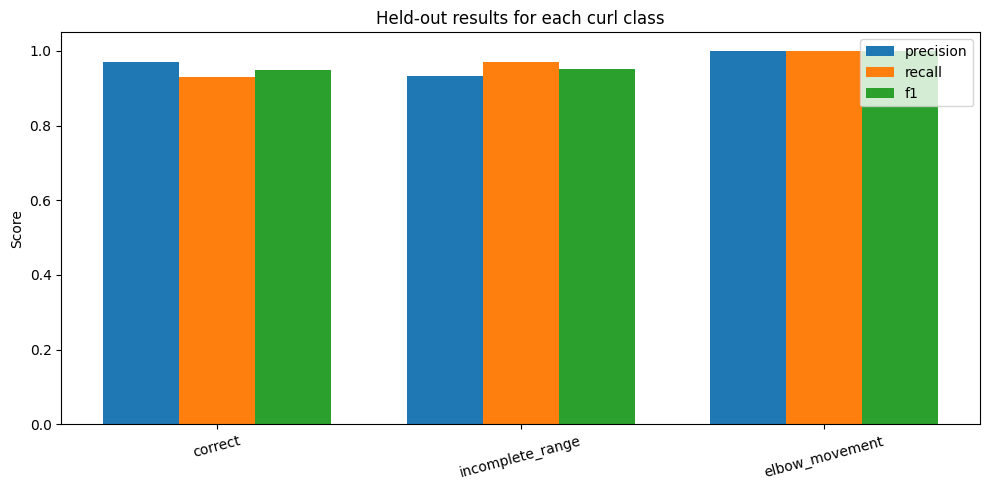

In [15]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

# Training versus test accuracy

x = np.arange(len(detailed_results))
width = 0.35

axes[0].bar(
    x - width / 2,
    detailed_results["train_accuracy"],
    width,
    label="Training accuracy",
    color="#2563eb"
)

axes[0].bar(
    x + width / 2,
    detailed_results["test_accuracy"],
    width,
    label="Held-out test accuracy",
    color="#f97316"
)

axes[0].set_xticks(
    x,
    [
        f"Fold {fold}"
        for fold in detailed_results["fold"]
    ]
)

axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training versus held-out test")
axes[0].legend()

# Balanced accuracy and macro F1

axes[1].bar(
    x - width / 2,
    detailed_results[
        "test_balanced_accuracy"
    ],
    width,
    label="Balanced accuracy",
    color="#16a34a"
)

axes[1].bar(
    x + width / 2,
    detailed_results["test_macro_f1"],
    width,
    label="Macro F1",
    color="#9333ea"
)

axes[1].set_xticks(
    x,
    [
        f"Fold {fold}"
        for fold in detailed_results["fold"]
    ]
)

axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score")
axes[1].set_title("Held-out test metrics")
axes[1].legend()

# Training time

axes[2].bar(
    [
        f"Fold {fold}"
        for fold in detailed_results["fold"]
    ],
    detailed_results["training_seconds"],
    color="#0891b2"
)

axes[2].set_ylabel("Seconds")
axes[2].set_title("Model training time")

plt.tight_layout()
plt.show()

# Combined held-out classification report

y_true = detailed_predictions[
    "class_id"
].to_numpy()

y_predicted = detailed_predictions[
    "predicted_class_id"
].to_numpy()

print("COMBINED HELD-OUT TEST REPORT")
print("-" * 60)

print(
    classification_report(
        y_true,
        y_predicted,
        labels=range(len(CLASS_NAMES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

# Confusion matrix

confusion = confusion_matrix(
    y_true,
    y_predicted,
    labels=range(len(CLASS_NAMES))
)

normalized_confusion = confusion_matrix(
    y_true,
    y_predicted,
    labels=range(len(CLASS_NAMES)),
    normalize="true"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

for axis, matrix, title, number_format in [
    (
        axes[0],
        confusion,
        "Held-out confusion matrix",
        "d"
    ),
    (
        axes[1],
        normalized_confusion,
        "Normalized held-out confusion matrix",
        ".2f"
    ),
]:
    image = axis.imshow(
        matrix,
        cmap="Blues",
        vmin=0,
        vmax=(
            1
            if number_format == ".2f"
            else None
        )
    )

    axis.set_xticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES,
        rotation=25,
        ha="right"
    )

    axis.set_yticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES
    )

    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
    axis.set_title(title)

    for row in range(len(CLASS_NAMES)):
        for column in range(len(CLASS_NAMES)):
            axis.text(
                column,
                row,
                format(
                    matrix[row, column],
                    number_format
                ),
                ha="center",
                va="center"
            )

    fig.colorbar(
        image,
        ax=axis,
        fraction=0.046,
        pad=0.04
    )

plt.tight_layout()
plt.show()

# Per-class metrics

precision, recall, class_f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_predicted,
        labels=range(len(CLASS_NAMES)),
        zero_division=0
    )
)

class_results = pd.DataFrame({
    "class": CLASS_NAMES,
    "precision": precision,
    "recall": recall,
    "f1": class_f1,
    "held_out_windows": support,
})

display(class_results.round(4))

x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.figure(figsize=(10, 5))

for offset, metric in enumerate(
    ["precision", "recall", "f1"]
):
    plt.bar(
        x + (offset - 1) * width,
        class_results[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    CLASS_NAMES,
    rotation=15
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Held-out results for each curl class")
plt.legend()
plt.tight_layout()
plt.show()

# ONNX live inference **speed**

In [16]:
if "onnx_session" not in globals():
    onnx_path = (
        DATASET_ROOT
        / "vantare_bicep_curl_v1.onnx"
    )

    onnx_session = ort.InferenceSession(
        str(onnx_path),
        providers=["CPUExecutionProvider"]
    )

    input_name = (
        onnx_session.get_inputs()[0].name
    )

benchmark_input = features[
    feature_names
].iloc[:1].to_numpy(dtype=np.float32)

# Warm up ONNX Runtime

for _ in range(20):
    onnx_session.run(
        None,
        {
            input_name: benchmark_input
        }
    )

number_of_runs = 1000

start_time = time.perf_counter()

for _ in range(number_of_runs):
    onnx_session.run(
        None,
        {
            input_name: benchmark_input
        }
    )

total_time = time.perf_counter() - start_time

average_inference_ms = (
    total_time
    / number_of_runs
    * 1000
)

predictions_per_second = (
    1000
    / average_inference_ms
)

print(
    f"Average ONNX inference time: "
    f"{average_inference_ms:.4f} ms"
)

print(
    f"Approximate model predictions per second: "
    f"{predictions_per_second:.2f}"
)

print(
    "\nThe application still produces only one new "
    "curl result every 0.5 seconds because the "
    "configured sensor-window stride is 0.5 seconds."
)

Average ONNX inference time: 0.1244 ms
Approximate model predictions per second: 8040.81

The application still produces only one new curl result every 0.5 seconds because the configured sensor-window stride is 0.5 seconds.
